# Fractured X-ray Image Augmentation

This notebook augments fractured X-ray images to address class imbalance, then organizes everything into the YOLO-compatible dataset structure.

## Problem
- Fractured images: 717
- Non-fractured images: 3366
- Ratio: ~1:4.7 (highly imbalanced)

For  more information about the dataset before augmentation, see [EDA.ipynb](EDA.ipynb)

## Solution
Apply realistic X-ray augmentations to **training-set fractured images only**, saving both
the augmented images and their transformed YOLO bounding-box labels.

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## Setting up for augmentation
This notebook runs the `augmentation` and `organize` python scripts found in the `\scripts\` directory.

More information is expounded in each section below.

In [ ]:
# download the zip file

--2026-03-05 14:40:30--  https://figshare.com/ndownloader/files/43283628
Resolving figshare.com (figshare.com)... 52.16.189.105, 34.243.188.211, 34.255.140.199
Connecting to figshare.com (figshare.com)|52.16.189.105|:443... connected.
HTTP request sent, awaiting response... 202 Accepted
Length: 0 [text/html]
Saving to: ‘../43283628’

43283628                [ <=>                ]       0  --.-KB/s    in 0s      

2026-03-05 14:40:32 (0.00 B/s) - ‘../43283628’ saved [0/0]



In [2]:
!mkdir datasets && cp -r ../FracAtlas/images ./datasets/images

A subdirectory or file datasets already exists.


## Augmentation Pipeline:
Because of the ratio of non-fracture to fracture was 4.7:1, we attempt to bridge the gap by adding more fractured images through augmentation for the set used to train the model.

The following techniques were utilized in the augmentation pipeline:
- Horizontal flips (50% probability) - bounding boxes transformed
- Rotations (±25 degrees, 50% probability) - bounding boxes transformed
- Affine shift/scale/rotate combinations (40% probability) - bounding boxes transformed
- Brightness/contrast adjustments (60% probability)
- Gaussian noise (35% probability)
- Gaussian blur (20% probability)
- Elastic transforms (15% probability)
- Gamma adjustment (35% probability)
- CLAHE enhancement (25% probability)

In [3]:
!python ../scripts/augment_with_labels.py --augmentations-per-image 3

Loading training split from: C:\Users\beaan\Downloads\1252\STINTSY\MP\STINTSYMCO1\notebook\Distribution\train.csv
Found 574 images in training set
Found 717 total fractured images

Augmenting 574 fractured images from training set
Creating 3 augmented versions per image
Total to create: 1722
Image output: C:\Users\beaan\Downloads\1252\STINTSY\MP\STINTSYMCO1\notebook\datasets\images\Fractured_Aug
Label output: C:\Users\beaan\Downloads\1252\STINTSY\MP\STINTSYMCO1\notebook\datasets\labels\Fractured_Aug
  Created 50/1722 augmented images...
  Created 100/1722 augmented images...
  Created 150/1722 augmented images...
Processed 50/574 original images
  Created 200/1722 augmented images...
  Created 250/1722 augmented images...
  Created 300/1722 augmented images...
Processed 100/574 original images
  Created 350/1722 augmented images...
  Created 400/1722 augmented images...
  Created 450/1722 augmented images...
Processed 150/574 original images
  Created 500/1722 augmented images...
  Cre

## Organize dataset

In [4]:
!python ../scripts/organize_dataset.py

DATASET ORGANIZATION
Notebook directory: C:\Users\beaan\Downloads\1252\STINTSY\MP\STINTSYMCO1\notebook
Output directory: C:\Users\beaan\Downloads\1252\STINTSY\MP\STINTSYMCO1\notebook\datasets\dataset
Include augmented: True
Dry run: False

Non-fractured split: 2695 train | 385 valid | 286 test

=== Organizing TRAIN split ===
Found 574 images in CSV
  Processed 50/574 images
  Processed 100/574 images
  Processed 150/574 images
  Processed 200/574 images
  Processed 250/574 images
  Processed 300/574 images
  Processed 350/574 images
  Processed 400/574 images
  Processed 450/574 images
  Processed 500/574 images
  Processed 550/574 images
  Processed 574/574 images

Adding all augmented images to training set...
Found 1722 augmented images
  Processed 50/1722 augmented images
  Processed 100/1722 augmented images
  Processed 150/1722 augmented images
  Processed 200/1722 augmented images
  Processed 250/1722 augmented images
  Processed 300/1722 augmented images
  Processed 350/1722 au

In [5]:
# path directory for the image dataset (Original unzipped dataset)
BASE_DIR          = Path.cwd()
DATA_DIR          = BASE_DIR / "datasets"
IMAGES_DIR        = DATA_DIR / "images"
FRACTURED_DIR     = IMAGES_DIR / "Fractured"
NON_FRACTURED_DIR = IMAGES_DIR / "Non_fractured"
FRACTURED_AUG_DIR = IMAGES_DIR / "Fractured_Aug"
LABELS_DIR        = DATA_DIR / "labels" / "Fractured_Aug"
YOLO_LABELS_DIR   = BASE_DIR / ".." / "FracAtlas" / "Annotations" / "YOLO"
DISTRIBUTION_DIR  = BASE_DIR / "Distribution"


Original fractured  : 717
Augmented fractured : 1722
Total fractured     : 2439
Non-fractured       : 3366
Old ratio  : 4.69:1
New ratio  : 1.38:1


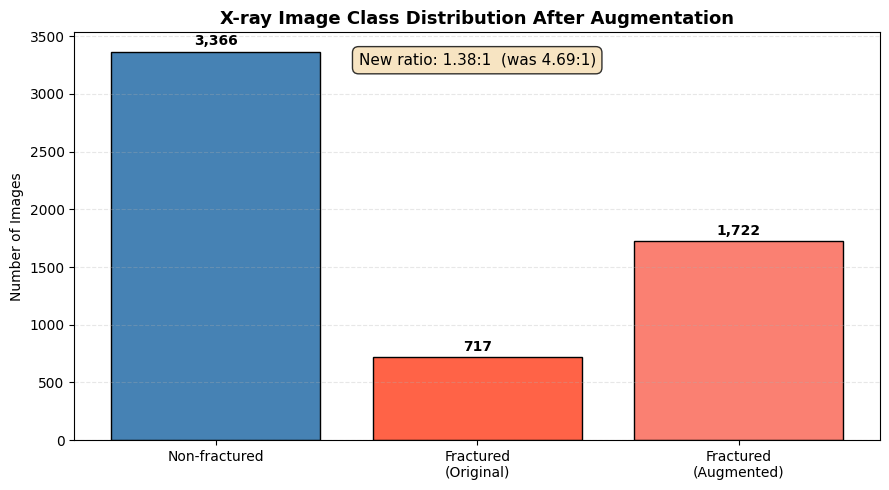

In [9]:
# counts the images in a folder
def count_images(folder):
    return sum(1 for _ in folder.glob("*.jpg")) + sum(1 for _ in folder.glob("*.png"))

# fractured vs non-fractured classes count
fractured_count     = count_images(FRACTURED_DIR)
non_fractured_count = count_images(NON_FRACTURED_DIR)

# fractured classes
actual_augmented = count_images(FRACTURED_AUG_DIR)
all_fractured    = fractured_count + actual_augmented

print(f"Original fractured  : {fractured_count}")
print(f"Augmented fractured : {actual_augmented}")
print(f"Total fractured     : {all_fractured}")
print(f"Non-fractured       : {non_fractured_count}")
print(f"Old ratio  : {non_fractured_count / fractured_count:.2f}:1")
print(f"New ratio  : {non_fractured_count / all_fractured:.2f}:1")

# bar chart that compared non-fractured, fractured-original, and fractured-augmented
fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Non-fractured', 'Fractured\n(Original)', 'Fractured\n(Augmented)']
counts     = [non_fractured_count, fractured_count, actual_augmented]
colors     = ['steelblue', 'tomato', 'salmon']
bars = ax.bar(categories, counts, color=colors, edgecolor='black')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('X-ray Image Class Distribution After Augmentation', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.text(0.5, 0.95,
        f'New ratio: {non_fractured_count / all_fractured:.2f}:1  (was {non_fractured_count / fractured_count:.2f}:1)',
        transform=ax.transAxes, ha='center', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

Because of augmentation, 1722 images were added to the `fractured` class. Which brings the old ratio from `4.69:1` to a more balanced ratio of `1.38:1`

Note that the augmented images are only added to the `train` set, and not `valid` nor `test` set.

To understand more about each of these splits, see the analysis shown below.

## Fracture vs Non-Fracture Count per Split

Here, we analyze the number of fractured and non-fractured images in each split of the final organized dataset (found in `datasets/dataset`).

Classification is determined by the YOLO label files:
- **Empty label file** → Non-fractured (no bounding box annotation)
- **Non-empty label file** → Fractured (contains bounding box annotation)

Split       Fractured   Non-Fractured    Total   Frac %
-------------------------------------------------------
Train           2,295           2,696    4,991    46.0%
Valid              82             385      467    17.6%
Test               61             286      347    17.6%


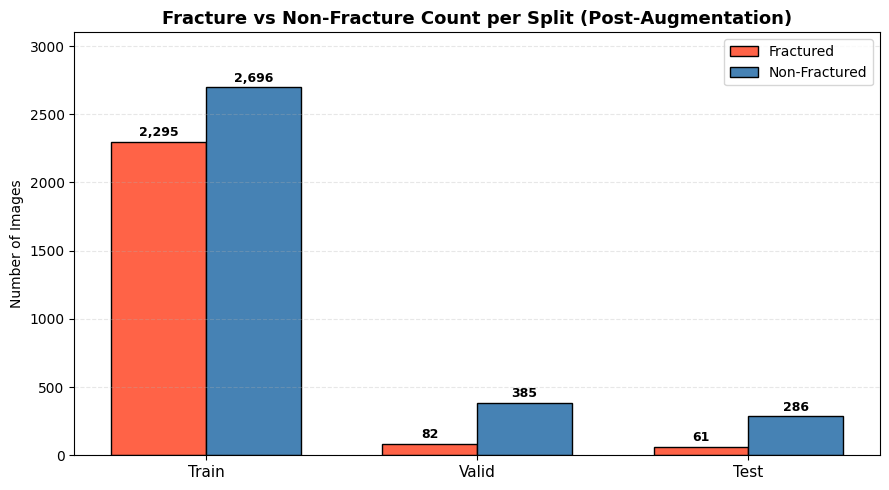

In [12]:
# paths for the image dataset after splitting
DATASET_DIR = Path.cwd() / "datasets" / "dataset"
SPLITS = ["train", "valid", "test"]

# counts how the dataset is split, and counts fractured vs non-fractured classing
split_counts = {}
for split in SPLITS:
    labels_dir = DATASET_DIR / split / "labels"
    label_files = list(labels_dir.glob("*.txt"))
    fractured     = sum(1 for f in label_files if f.stat().st_size > 0) # fractured: label has content
    non_fractured = sum(1 for f in label_files if f.stat().st_size == 0) # non-fractured: label is empty
    total         = len(label_files)
    split_counts[split] = {
        "fractured":     fractured,
        "non_fractured": non_fractured,
        "total":         total,
    }

# summary table comparing the train, valid, test split for fractured vs non-fractured class
print(f"{'Split':<8} {'Fractured':>12} {'Non-Fractured':>15} {'Total':>8} {'Frac %':>8}")
print("-" * 55)
for split, counts in split_counts.items():
    pct = counts["fractured"] / counts["total"] * 100
    print(f"{split.capitalize():<8} {counts['fractured']:>12,} {counts['non_fractured']:>15,} "
          f"{counts['total']:>8,} {pct:>7.1f}%")

# formats the bar chart
x        = np.arange(len(SPLITS))
width    = 0.35
frac_vals    = [split_counts[s]["fractured"]     for s in SPLITS]
nonfrac_vals = [split_counts[s]["non_fractured"] for s in SPLITS]

fig, ax = plt.subplots(figsize=(9, 5))
bars_frac    = ax.bar(x - width / 2, frac_vals,    width, label="Fractured",     color="tomato",    edgecolor="black")
bars_nonfrac = ax.bar(x + width / 2, nonfrac_vals, width, label="Non-Fractured", color="steelblue", edgecolor="black")

for bar in bars_frac + bars_nonfrac:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SPLITS], fontsize=11)
ax.set_ylabel("Number of Images")
ax.set_title("Fracture vs Non-Fracture Count per Split (Post-Augmentation)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_ylim(0, max(nonfrac_vals) * 1.15)
plt.tight_layout()
plt.show()

## Summary
The graph above displays how the augmented images were able to bridge the gap between the `fractured` and `non-fractured` images in the `train` set. But for the `valid` and `test` set, no augmentation is performed.